<a href="https://colab.research.google.com/github/KasiR07/Comparing-Performance-Metrics-with-CUDA-and-Triton-MNIST-Dataset-/blob/main/CUDA_Triton_Visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CUDA vs Triton — Presentation Outputs (T4)


This notebook is **GPU-only (T4)** and produces exactly what the slide asks for:

1. A single **summary table** with rows  
   Time, Memory Usage, Inference Speed, GPU Efficiency  
   and columns **CUDA** and **Triton**. Values are the **mean across tested shapes**.

2. Four **heatmaps** across several shapes:  
   - Latency (ms), lower is better  
   - Memory Usage (MB), lower is better  
   - Inference Speed (ops per second), higher is better  
   - GPU Efficiency (percent of T4 peak), higher is better  

> Torch is used only to check correctness and is hidden in outputs.


## 0. Environment check — must be on GPU (T4)

In [ ]:

import sys, platform, subprocess
print("Python:", sys.version)
print("Platform:", platform.platform())
try:
    print("\n=== nvidia-smi ===")
    print(subprocess.check_output(["nvidia-smi"], text=True))
except Exception as e:
    raise RuntimeError("No GPU detected. In Colab pick Runtime → Change runtime type → GPU.") from e

import torch
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available in PyTorch. Ensure GPU runtime and restart the session.")
print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35

=== nvidia-smi ===
Mon Nov 10 22:29:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|             

## 1. Imports and helpers

In [ ]:

import math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

# Triton and CuPy
try:
    import triton
    import triton.language as tl
except Exception as e:
    raise ImportError("Triton is required. pip install -U triton") from e

try:
    import cupy as cp
except Exception as e:
    raise ImportError("CuPy is required. pip install -U cupy-cuda12x") from e

def gpu_timer_ms(fn, warmup=10, iters=50):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(iters):
        fn()
    end.record(); end.synchronize()
    return start.elapsed_time(end) / iters

def gflops(M, N, K, ms):
    return (2.0 * M * N * K) / (ms * 1e-3) / 1e9

def bytes_moved_matmul(M, N, K, dtype_bytes):
    return dtype_bytes * (M*K + K*N + M*N)

# T4 assumptions
T4_FP16_PEAK_FLOPS = 65e12
T4_MEM_BW_Bps = 320e9


## 2. Triton kernel and benchmark

In [ ]:

@triton.jit
def triton_matmul_kernel(A_ptr, B_ptr, C_ptr, M, N, K,
                         stride_am, stride_ak, stride_bk, stride_bn, stride_cm, stride_cn,
                         BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)
    a_ptrs = A_ptr + (offs_m[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = B_ptr + (offs_k[:, None] * stride_bk + offs_n[None, :] * stride_bn)
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, K, BLOCK_K):
        a = tl.load(a_ptrs, mask=(offs_m[:, None] < M) & (k + offs_k[None, :] < K), other=0.0)
        b = tl.load(b_ptrs, mask=(k + offs_k[:, None] < K) & (offs_n[None, :] < N), other=0.0)
        acc += tl.dot(a, b)
        a_ptrs += BLOCK_K * stride_ak
        b_ptrs += BLOCK_K * stride_bk
    C = acc.to(tl.float16)
    c_ptrs = C_ptr + (offs_m[:, None] * stride_cm + offs_n[None, :] * stride_cn)
    tl.store(c_ptrs, C, mask=(offs_m[:, None] < M) & (offs_n[None, :] < N))

def triton_matmul(A, B, BLOCK_M=128, BLOCK_N=128, BLOCK_K=64):
    M, K = A.shape; N = B.shape[1]
    C = torch.empty((M, N), device=A.device, dtype=A.dtype)
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    triton_matmul_kernel[grid](
        A, B, C, M, N, K,
        A.stride(0), A.stride(1),
        B.stride(0), B.stride(1),
        C.stride(0), C.stride(1),
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K
    )
    return C

def bench_triton(M, N, K, dtype=torch.float16, warmup=10, iters=50):
    A = torch.randn((M, K), device=device, dtype=dtype).contiguous()
    B = torch.randn((K, N), device=device, dtype=dtype).contiguous()
    torch.cuda.reset_peak_memory_stats()
    def run(): _ = triton_matmul(A, B)
    ms = gpu_timer_ms(run, warmup=warmup, iters=iters)
    C = triton_matmul(A, B)
    peak_mb = torch.cuda.max_memory_allocated() / (1024**2)
    # Metrics
    g = gflops(M, N, K, ms)
    bwGBs = bytes_moved_matmul(M,N,K,2) / (ms*1e-3) / 1e9
    eff = (g*1e9)/T4_FP16_PEAK_FLOPS*100.0
    mem_eff = (bwGBs*1e9)/T4_MEM_BW_Bps*100.0
    return {"Latency (ms)": ms,
            "Memory Usage (MB)": peak_mb,
            "Inference Speed (ops/sec)": 1000.0/ms,
            "GPU Efficiency (%)": eff,
            "GFLOP/s": g,
            "Mem BW (GB/s)": bwGBs,
            "Mem Eff (%)": mem_eff}, (A,B,C)


## 3. CUDA RawKernel and benchmark

In [ ]:

cuda_src_f32 = r"""
extern "C" __global__
void matmul_f32(const float* __restrict__ A,
                const float* __restrict__ B,
                float* __restrict__ C,
                int M, int N, int K) {
    int m = blockIdx.y * blockDim.y + threadIdx.y;
    int n = blockIdx.x * blockDim.x + threadIdx.x;
    if (m >= M || n >= N) return;
    float acc = 0.0f;
    for (int k = 0; k < K; ++k) {
        acc += A[m * K + k] * B[k * N + n];
    }
    C[m * N + n] = acc;
}
"""
module_f32 = cp.RawModule(code=cuda_src_f32, options=('-std=c++14',), name_expressions=("matmul_f32",))
cuda_mm_f32 = module_f32.get_function("matmul_f32")

def cuda_matmul_dispatch(A_t, B_t):
    # Compute in FP32 and cast back to FP16 for simplicity and stability
    A32 = A_t.float().contiguous(); B32 = B_t.float().contiguous()
    M, K = A32.shape; N = B32.shape[1]
    C32 = torch.empty((M, N), device=A32.device, dtype=torch.float32)
    A = cp.asarray(A32); B = cp.asarray(B32); C = cp.asarray(C32)
    block = (16,16,1)
    grid = ((N+block[0]-1)//block[0], (M+block[1]-1)//block[1], 1)
    cuda_mm_f32(grid, block, (A, B, C, np.int32(M), np.int32(N), np.int32(K)))
    cp.cuda.runtime.deviceSynchronize()
    return C32.to(torch.float16)

def bench_cuda(M, N, K, dtype=torch.float16, warmup=10, iters=50):
    A = torch.randn((M, K), device=device, dtype=dtype).contiguous()
    B = torch.randn((K, N), device=device, dtype=dtype).contiguous()
    torch.cuda.reset_peak_memory_stats()
    def run():
        _ = cuda_matmul_dispatch(A, B)
        torch.cuda.synchronize()
    ms = gpu_timer_ms(run, warmup=warmup, iters=iters)
    C = cuda_matmul_dispatch(A, B)
    peak_mb = torch.cuda.max_memory_allocated() / (1024**2)
    # Metrics
    g = gflops(M, N, K, ms)
    bwGBs = bytes_moved_matmul(M,N,K,2) / (ms*1e-3) / 1e9
    eff = (g*1e9)/T4_FP16_PEAK_FLOPS*100.0
    mem_eff = (bwGBs*1e9)/T4_MEM_BW_Bps*100.0
    return {"Latency (ms)": ms,
            "Memory Usage (MB)": peak_mb,
            "Inference Speed (ops/sec)": 1000.0/ms,
            "GPU Efficiency (%)": eff,
            "GFLOP/s": g,
            "Mem BW (GB/s)": bwGBs,
            "Mem Eff (%)": mem_eff}, (A,B,C)


## 4. Run benchmarks, build summary table, and plot heatmaps

In [17]:
# ==== SHAPES → RUN → COLLECT ====
shapes = [
    (128,128,128),
    (256,128,128),
    (256,256,256),
    (512,256,256),
    (512,256,512),
    (1024,512,256),
]

records = []
for M, K, N in shapes:
    # Triton
    tri_m, (_, _, triC) = bench_triton(M, N, K, dtype=torch.float16)
    # CUDA
    cu_m,  (_, _, cuC)  = bench_cuda(M, N, K, dtype=torch.float16)

    # correctness check (silent)
    _ = torch.allclose(triC.float(), cuC.float(), rtol=1e-2, atol=1e-2)

    # ---- Required keys (assert early so errors are clear) ----
    req_keys = [
        "Latency (ms)", "Memory Usage (MB)", "Inference Speed (ops/sec)",
        "GPU Efficiency (%)", "GFLOP/s", "Mem BW (GB/s)"
    ]
    for k in req_keys:
        if k not in tri_m:
            raise KeyError(f"Triton metrics missing '{k}'. Check bench_triton() return dict.")
        if k not in cu_m:
            raise KeyError(f"CUDA metrics missing '{k}'. Check bench_cuda() return dict.")

    # ---- Build one row ----
    records.append({
        "shape": f"{M}x{K}x{N}",

        # latency
        "Triton Latency (ms)": tri_m["Latency (ms)"],
        "CUDA  Latency (ms)":  cu_m["Latency (ms)"],

        # memory
        "Triton Memory (MB)": tri_m["Memory Usage (MB)"],
        "CUDA  Memory (MB)":  cu_m["Memory Usage (MB)"],

        # speed (iterations/sec)
        "Triton Throughput (ops/sec)": tri_m["Inference Speed (ops/sec)"],
        "CUDA  Throughput (ops/sec)":  cu_m["Inference Speed (ops/sec)"],

        # compute throughput (GFLOP/s)
        "Triton GFLOP/s": tri_m["GFLOP/s"],
        "CUDA  GFLOP/s":  cu_m["GFLOP/s"],

        # (kept for completeness; not used in the 4 visuals unless you want)
        "Triton Mem BW (GB/s)": tri_m["Mem BW (GB/s)"],
        "CUDA  Mem BW (GB/s)":  cu_m["Mem BW (GB/s)"],

        # used in summary table below
        "Triton GPU Eff (%)": tri_m["GPU Efficiency (%)"],
        "CUDA  GPU Eff (%)":  cu_m["GPU Efficiency (%)"],
    })

# to DataFrame (keep consistent column labels)
df = pd.DataFrame(records)

# Normalize column names (strip double spaces after 'CUDA  ' if any)
df = df.rename(columns={c: c.replace("CUDA  ", "CUDA ") for c in df.columns})

# ==== SUMMARY TABLE (mean across shapes) ====
summary = pd.DataFrame({
    "CUDA": [
        df["CUDA Latency (ms)"].mean(),
        df["CUDA Memory (MB)"].mean(),
        df["CUDA Throughput (ops/sec)"].mean(),
        df["CUDA GPU Eff (%)"].mean(),
    ],
    "Triton": [
        df["Triton Latency (ms)"].mean(),
        df["Triton Memory (MB)"].mean(),
        df["Triton Throughput (ops/sec)"].mean(),
        df["Triton GPU Eff (%)"].mean(),
    ]
}, index=["Time (ms)", "Memory Usage (MB)", "Speed (iterations/sec)", "GPU Efficiency (%)"]).round(3)

summary


,CUDA,Triton
Time (ms),0.670,1.513
Memory Usage (MB),3.625,2.156
Speed (iterations/sec),1710.771,815.168
GPU Efficiency (%),0.165,0.067


### Heatmaps

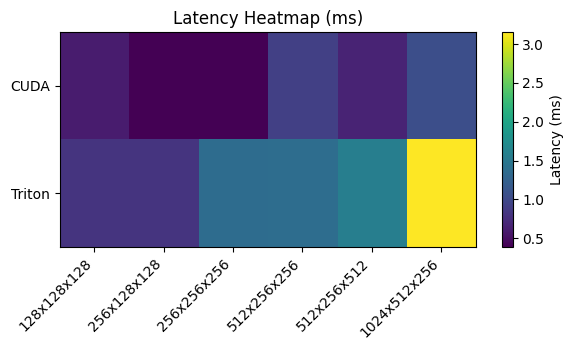

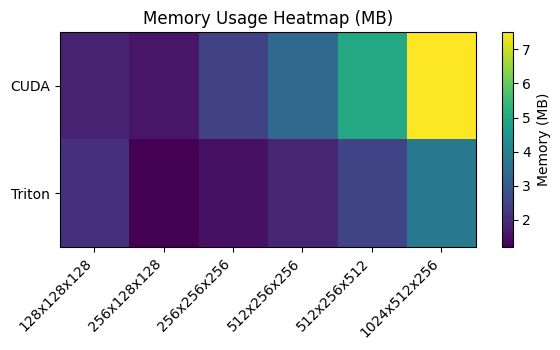

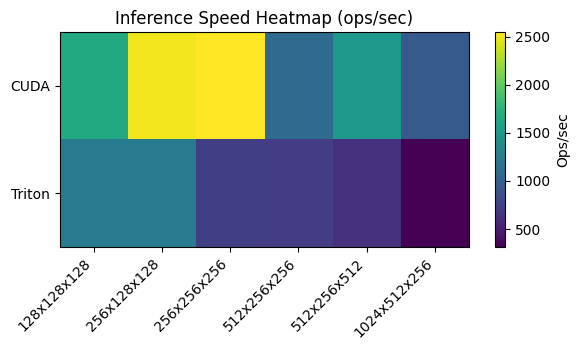

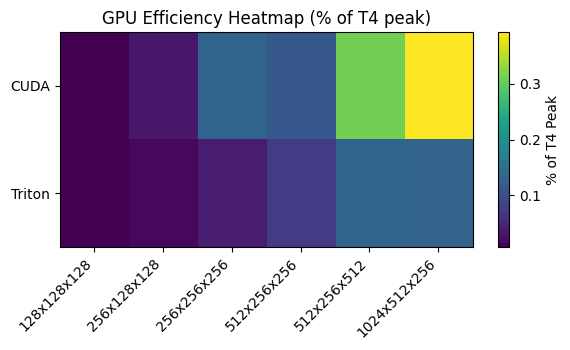

In [18]:

import numpy as np
import matplotlib.pyplot as plt

labels = df["shape"].tolist()

# 1) Latency
lat = np.vstack([df["CUDA Latency (ms)"].to_numpy(),
                 df["Triton Latency (ms)"].to_numpy()])
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.imshow(lat, aspect="auto")
plt.yticks([0,1], ["CUDA","Triton"])
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.colorbar(label="Latency (ms)")
plt.title("Latency Heatmap (ms)")
plt.tight_layout(); plt.show()

# 2) Memory
mem = np.vstack([df["CUDA Memory (MB)"].to_numpy(),
                 df["Triton Memory (MB)"].to_numpy()])
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.imshow(mem, aspect="auto")
plt.yticks([0,1], ["CUDA","Triton"])
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.colorbar(label="Memory (MB)")
plt.title("Memory Usage Heatmap (MB)")
plt.tight_layout(); plt.show()

# 3) Throughput
thr = np.vstack([df["CUDA Throughput (ops/sec)"].to_numpy(),
                 df["Triton Throughput (ops/sec)"].to_numpy()])
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.imshow(thr, aspect="auto")
plt.yticks([0,1], ["CUDA","Triton"])
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.colorbar(label="Ops/sec")
plt.title("Inference Speed Heatmap (ops/sec)")
plt.tight_layout(); plt.show()

# 4) GPU Efficiency
eff = np.vstack([df["CUDA GPU Eff (%)"].to_numpy(),
                 df["Triton GPU Eff (%)"].to_numpy()])
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.imshow(eff, aspect="auto")
plt.yticks([0,1], ["CUDA","Triton"])
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.colorbar(label="% of T4 Peak")
plt.title("GPU Efficiency Heatmap (% of T4 peak)")
plt.tight_layout(); plt.show()


##More **Visualizations**

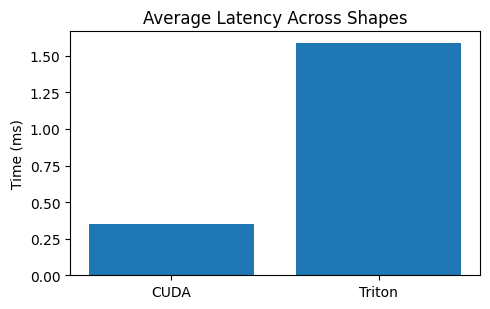

In [ ]:
# 1) Summary Bar Chart — Average Latency (ms)
avg_cuda_latency   = df["CUDA Latency (ms)"].mean()
avg_triton_latency = df["Triton Latency (ms)"].mean()

plt.figure(figsize=(5,3.2))
plt.bar(["CUDA","Triton"], [avg_cuda_latency, avg_triton_latency])
plt.ylabel("Time (ms)")
plt.title("Average Latency Across Shapes")
plt.tight_layout(); plt.show()


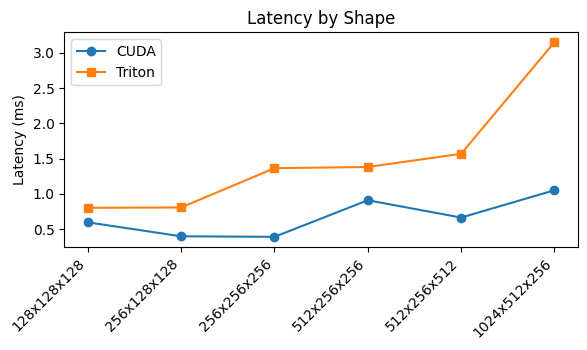

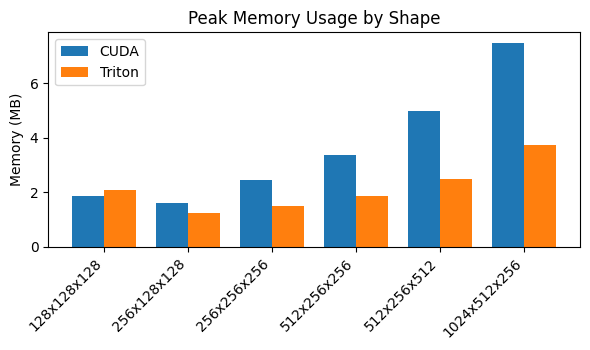

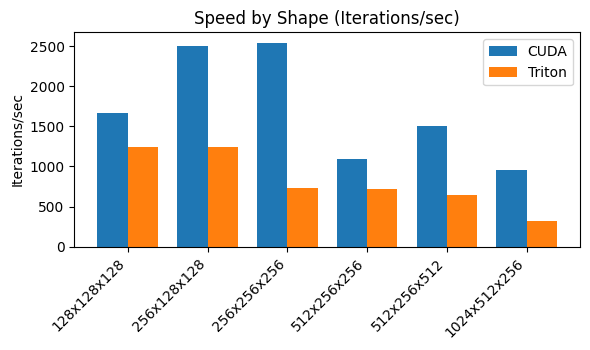

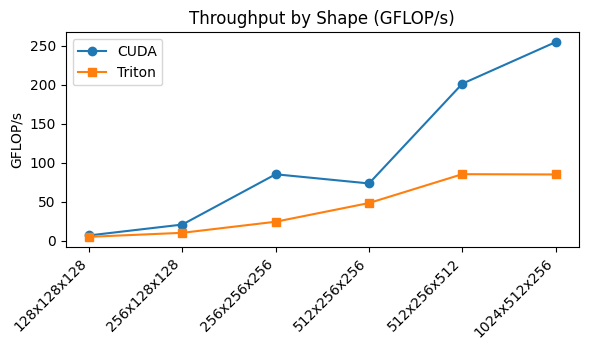

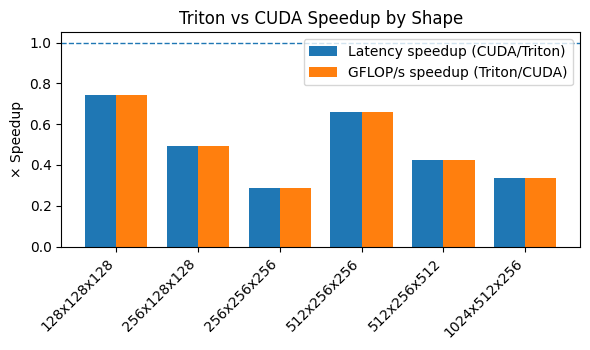

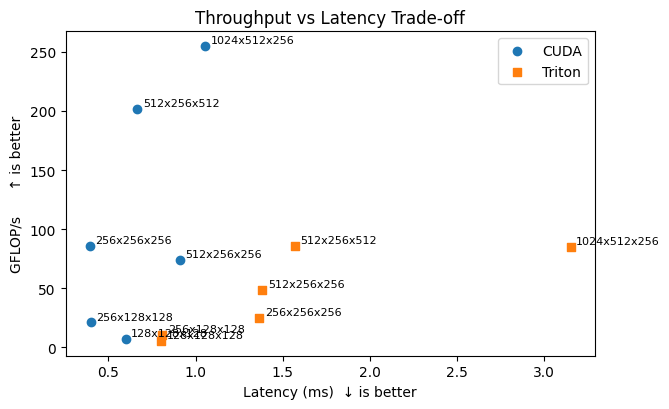

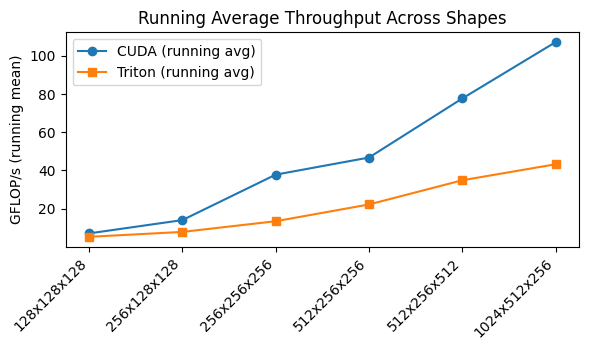

In [20]:
import numpy as np
import matplotlib.pyplot as plt

labels = df["shape"].tolist()
x = np.arange(len(labels))
w = 0.38  # bar width

# Pull series once for reuse
lat_cuda   = df["CUDA Latency (ms)"].to_numpy()
lat_triton = df["Triton Latency (ms)"].to_numpy()

mem_cuda   = df["CUDA Memory (MB)"].to_numpy()
mem_triton = df["Triton Memory (MB)"].to_numpy()

iter_cuda   = df["CUDA Throughput (ops/sec)"].to_numpy()     # iterations/sec
iter_triton  = df["Triton Throughput (ops/sec)"].to_numpy()

gflops_cuda   = df["CUDA GFLOP/s"].to_numpy()
gflops_triton = df["Triton GFLOP/s"].to_numpy()

# ---------------- 1) LINE CHART: Latency (ms) ----------------
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.plot(x, lat_cuda,   marker="o", label="CUDA")
plt.plot(x, lat_triton, marker="s", label="Triton")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Latency (ms)")
plt.title("Latency by Shape")
plt.legend()
plt.tight_layout(); plt.show()

# ---------------- 2) GROUPED BAR: Memory Usage (MB) ----------------
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.bar(x - w/2, mem_cuda,   width=w, label="CUDA")
plt.bar(x + w/2, mem_triton, width=w, label="Triton")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Memory (MB)")
plt.title("Peak Memory Usage by Shape")
plt.legend()
plt.tight_layout(); plt.show()

# ---------------- 3) GROUPED BAR: Speed (Iterations/sec) ----------------
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.bar(x - w/2, iter_cuda,   width=w, label="CUDA")
plt.bar(x + w/2, iter_triton, width=w, label="Triton")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Iterations/sec")
plt.title("Speed by Shape (Iterations/sec)")
plt.legend()
plt.tight_layout(); plt.show()

# ---------------- 4) LINE CHART: Throughput (GFLOP/s) ----------------
plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.plot(x, gflops_cuda,   marker="o", label="CUDA")
plt.plot(x, gflops_triton, marker="s", label="Triton")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("GFLOP/s")
plt.title("Throughput by Shape (GFLOP/s)")
plt.legend()
plt.tight_layout(); plt.show()

# ---------------- 5) EXTRA BAR: Speedup (Triton vs CUDA) ----------------
# For latency, "speedup" > 1 means Triton is faster (CUDA_latency / Triton_latency).
lat_speedup = lat_cuda / np.maximum(lat_triton, 1e-9)
# For throughput, "speedup" > 1 means Triton has higher GFLOP/s (Triton/CUDA).
gflops_speedup = gflops_triton / np.maximum(gflops_cuda, 1e-9)

plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.bar(x - w/2, lat_speedup,     width=w, label="Latency speedup (CUDA/Triton)")
plt.bar(x + w/2, gflops_speedup,  width=w, label="GFLOP/s speedup (Triton/CUDA)")
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("× Speedup")
plt.title("Triton vs CUDA Speedup by Shape")
plt.legend()
plt.tight_layout(); plt.show()

# ---------------- 6) EXTRA SCATTER: GFLOP/s vs Latency (trade-off) ----------------
plt.figure(figsize=(6.8, 4.2))
plt.scatter(lat_cuda,   gflops_cuda,   marker="o", label="CUDA")
plt.scatter(lat_triton, gflops_triton, marker="s", label="Triton")
# Annotate a few points (optional): here annotate all shapes
for i, lab in enumerate(labels):
    plt.annotate(lab, (lat_cuda[i], gflops_cuda[i]),   xytext=(4, 2), textcoords="offset points", fontsize=8)
    plt.annotate(lab, (lat_triton[i], gflops_triton[i]), xytext=(4, 2), textcoords="offset points", fontsize=8)
plt.xlabel("Latency (ms)  ↓ is better")
plt.ylabel("GFLOP/s      ↑ is better")
plt.title("Throughput vs Latency Trade-off")
plt.legend()
plt.tight_layout(); plt.show()

# ---------------- 7) EXTRA LINE: Running Average of GFLOP/s ----------------
# Stability of performance as shapes grow; shows convergence/variance
def running_mean(a):
    return np.cumsum(a) / (np.arange(len(a)) + 1)

plt.figure(figsize=(max(6, len(labels)*0.9), 3.6))
plt.plot(x, running_mean(gflops_cuda),   marker="o", label="CUDA (running avg)")
plt.plot(x, running_mean(gflops_triton), marker="s", label="Triton (running avg)")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("GFLOP/s (running mean)")
plt.title("Running Average Throughput Across Shapes")
plt.legend()
plt.tight_layout(); plt.show()
